# Data Coverage & Quality Review (Dry-Only)

Systematic review of the processed F1 tire degradation dataset. This dataset contains **dry compound laps only** (SOFT, MEDIUM, HARD) — wet/intermediate laps are separated into `laps_wet.parquet`.

In [1]:
import json
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

DATA_DIR = Path("../data/processed")

sns.set_theme(style="whitegrid", palette="colorblind")
pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 60)

## 1. Load & Overview

In [2]:
df = pd.read_parquet(DATA_DIR / "laps_clean.parquet")
with open(DATA_DIR / "metadata.json") as f:
    meta = json.load(f)

print(f"Shape: {df.shape}")
print(f"Memory: {df.memory_usage(deep=True).sum() / 1e6:.1f} MB")
print(
    f"Races: {df['race_id'].nunique()}, Circuits: {df['circuit_id'].nunique()}, Drivers: {df['driver_id'].nunique()}"
)
print(f"Compounds: {df['compound'].value_counts().to_dict()}")
print(f"\nColumns ({len(df.columns)}):")
print(list(df.columns))

# Also load wet data for reference
wet_path = DATA_DIR / "laps_wet.parquet"
if wet_path.exists():
    wet_df = pd.read_parquet(wet_path)
    print(f"\nWet dataset: {len(wet_df)} laps ({wet_df['compound'].value_counts().to_dict()})")

Shape: (78217, 54)
Memory: 58.4 MB
Races: 90, Circuits: 25, Drivers: 31
Compounds: {'HARD': 37852, 'MEDIUM': 30453, 'SOFT': 9912}

Columns (54):
['race_id', 'circuit_id', 'track_length_km', 'n_corners', 'tire_stress', 'pit_loss_seconds', 'driver_id', 'constructor_id', 'lap_number', 'lap_time_seconds', 'tyre_life', 'tyre_life_sq', 'compound', 'fuel_mass_kg', 'air_temp', 'track_temp', 'humidity', 'pressure', 'wind_speed', 'wind_direction', 'rainfall', 'stint_number', 'stint_lap', 'TrackStatus', 'position', 'gap_ahead_seconds', 'gap_behind_seconds', 'position_change', 'traffic_density', 'race_progress', 'stint_fraction', 'is_final_stint', 'track_temp_delta', 'drs_likely', 'compound_x_track_temp', 'tyre_life_x_compound', 'fuel_mass_x_track_temp', 'humidity_x_rainfall', 'laps_since_sc_end', 'laps_since_red_flag', 'had_sc_this_stint', 'compound_class', 'is_wet_running', 'compound_class_changed_this_stint', 'laps_since_compound_class_change', 'sub_race_id', 'circuit_baseline_pace', 'driver_pa

In [3]:
df.head(3)

,race_id,circuit_id,track_length_km,n_corners,tire_stress,pit_loss_seconds,driver_id,constructor_id,lap_number,lap_time_seconds,tyre_life,tyre_life_sq,compound,fuel_mass_kg,air_temp,track_temp,humidity,pressure,wind_speed,wind_direction,rainfall,stint_number,stint_lap,TrackStatus,position,gap_ahead_seconds,gap_behind_seconds,position_change,traffic_density,race_progress,stint_fraction,is_final_stint,track_temp_delta,drs_likely,compound_x_track_temp,tyre_life_x_compound,fuel_mass_x_track_temp,humidity_x_rainfall,laps_since_sc_end,laps_since_red_flag,had_sc_this_stint,compound_class,is_wet_running,compound_class_changed_this_stint,laps_since_compound_class_change,sub_race_id,circuit_baseline_pace,driver_pace_vs_field,fp_deg_rate_soft,fp_deg_rate_medium,fp_deg_rate_hard,weekend_track_temp,quali_position,expected_fp3_race_delta
0,2022_01,Bahrain Grand Prix,5.412,15,3,22.5,VER,Red Bull Racing,2,97.880,5.0,25.0,SOFT,108.5,23.9,29.0,26.0,1010.4,0.3,13,False,1,1,1,2.0,1.193,1.539,NaN,5,0.035088,0.083333,False,0.000000,0.0,0.0,0.0,3146.5,0.0,5.0,5.0,False,dry,0.0,0.0,10.0,1,97.808,1.073,0.287632,0.370333,0.14152,31.48982,2.0,1.069833
1,2022_01,Bahrain Grand Prix,5.412,15,3,22.5,VER,Red Bull Racing,3,98.357,6.0,36.0,SOFT,107.0,23.8,29.0,27.0,1010.4,0.5,12,False,1,2,1,2.0,1.278,2.231,0.0,5,0.052632,0.166667,False,0.000000,0.0,0.0,0.0,3103.0,0.0,5.0,5.0,False,dry,0.0,0.0,10.0,1,97.808,1.073,0.287632,0.370333,0.14152,31.48982,2.0,1.069833
2,2022_01,Bahrain Grand Prix,5.412,15,3,22.5,VER,Red Bull Racing,4,98.566,7.0,49.0,SOFT,105.5,23.8,28.8,29.0,1010.2,0.4,13,False,1,3,1,2.0,1.430,2.588,0.0,6,0.070175,0.250000,False,-0.066667,0.0,0.0,0.0,3038.4,0.0,5.0,5.0,False,dry,0.0,0.0,10.0,1,97.808,1.073,0.287632,0.370333,0.14152,31.48982,2.0,1.069833


In [4]:
df.dtypes

race_id                               object
circuit_id                            object
track_length_km                      float64
n_corners                              int64
tire_stress                            int64
pit_loss_seconds                     float64
driver_id                             object
constructor_id                        object
lap_number                             int64
lap_time_seconds                     float64
tyre_life                            float64
tyre_life_sq                         float64
compound                              object
fuel_mass_kg                         float64
air_temp                             float64
track_temp                           float64
humidity                             float64
pressure                             float64
wind_speed                           float64
wind_direction                         int64
rainfall                                bool
stint_number                           int64
stint_lap 

In [5]:
df.describe()

,track_length_km,n_corners,tire_stress,pit_loss_seconds,lap_number,lap_time_seconds,tyre_life,tyre_life_sq,fuel_mass_kg,air_temp,track_temp,humidity,pressure,wind_speed,wind_direction,stint_number,stint_lap,position,gap_ahead_seconds,gap_behind_seconds,position_change,traffic_density,race_progress,stint_fraction,track_temp_delta,drs_likely,compound_x_track_temp,tyre_life_x_compound,fuel_mass_x_track_temp,humidity_x_rainfall,laps_since_sc_end,laps_since_red_flag,is_wet_running,compound_class_changed_this_stint,laps_since_compound_class_change,sub_race_id,circuit_baseline_pace,driver_pace_vs_field,fp_deg_rate_soft,fp_deg_rate_medium,fp_deg_rate_hard,weekend_track_temp,quali_position,expected_fp3_race_delta
count,78217.000000,78217.000000,78217.000000,78217.000000,78217.000000,78217.000000,78217.000000,78217.000000,78217.000000,78217.000000,78217.000000,78217.000000,78217.000000,78217.000000,78217.000000,78217.000000,78217.000000,78217.000000,73859.000000,74412.000000,76866.000000,78217.000000,78217.000000,78217.000000,78217.000000,78217.000000,78217.000000,78217.000000,78217.000000,78217.000000,78217.000000,78217.000000,78217.0,78217.000000,78217.000000,78217.000000,78217.000000,78217.000000,78217.000000,78217.000000,78217.000000,78217.000000,78217.000000,78217.000000
mean,5.070986,16.553332,2.989031,22.894211,31.675735,88.509610,15.329353,337.502742,63.989529,24.336031,36.110013,51.325927,984.706578,1.844724,182.405014,1.884718,13.316964,9.662708,4.562760,4.767156,-0.014181,12.821241,0.516758,0.525733,-0.003080,0.219044,48.890373,22.249575,2326.055871,0.547029,4.755104,4.989977,0.0,0.040439,9.947901,1.064232,86.226575,0.386845,0.295783,0.157827,0.117111,38.878821,10.255230,3.027693
std,0.810463,3.417386,0.882728,0.779785,17.682526,10.570992,10.124969,469.276126,26.516027,4.693854,8.586860,16.636362,55.908000,1.104252,98.043505,0.770458,10.034581,5.384065,7.070654,18.666642,0.941222,3.999131,0.279038,0.287016,0.404891,0.413601,28.062877,21.098122,1174.117895,6.093824,0.915584,0.158628,0.0,0.196987,0.574739,0.245167,10.952502,1.427965,0.087183,0.078573,0.045628,7.769156,5.724382,2.122939
min,3.337000,10.000000,1.000000,21.000000,2.000000,67.012000,1.000000,1.000000,0.000000,13.100000,15.600000,5.000000,778.500000,0.000000,0.000000,1.000000,1.000000,1.000000,0.002000,0.000000,-9.000000,0.000000,0.025641,0.013158,-3.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.0,0.000000,1.000000,1.000000,66.885000,-3.621000,0.011875,0.001758,0.002830,15.162249,1.000000,-1.668500
25%,4.361000,14.000000,2.000000,22.500000,17.000000,80.463000,8.000000,64.000000,44.000000,20.600000,30.300000,39.000000,987.000000,1.100000,112.000000,1.000000,6.000000,5.000000,1.030500,1.032000,0.000000,10.000000,0.277778,0.277778,-0.133333,0.000000,31.200000,7.000000,1390.400000,0.000000,5.000000,5.000000,0.0,0.000000,10.000000,1.000000,77.439000,-0.485500,0.233790,0.093774,0.092086,34.829412,5.000000,1.689750
50%,5.278000,16.000000,3.000000,23.000000,31.000000,86.645000,13.000000,169.000000,65.000000,25.000000,35.600000,53.000000,1007.100000,1.600000,183.000000,2.000000,11.000000,10.000000,2.299000,2.322000,0.000000,14.000000,0.515152,0.525000,-0.033333,0.000000,46.900000,16.000000,2219.650000,0.000000,5.000000,5.000000,0.0,0.000000,10.000000,1.000000,84.148000,0.166000,0.295055,0.143950,0.117972,39.129070,10.000000,2.844000
75%,5.793000,19.000000,4.000000,23.500000,45.000000,97.058000,21.000000,441.000000,86.000000,28.100000,43.100000,64.000000,1013.500000,2.400000,265.000000,2.000000,19.000000,14.000000,5.227000,5.340250,0.000000,16.000000,0.758621,0.772727,0.066667,0.000000,71.000000,32.000000,3131.100000,0.000000,5.000000,5.000000,0.0,0.000000,10.000000,1.000000,94.384000,0.955000,0.362931,0.199945,0.140617,43.004372,15.000000,4.436500
max,7.004000,27.000000,5.000000,24.000000,78.000000,122.097000,78.000000,6084.000000,108.500000,37.200000,57.500000,89.000000,1021.900000,8.600000,359.000000,6.000000,76.000000,20.000000,142.639000,3916.20

## 2. Data Coverage

In [6]:
df["season"] = df["race_id"].str[:4].astype(int)

### Races & laps per season

,races,laps,drivers,circuits
season,,,,
2022,21,16846,22,21
2023,22,19582,22,22
2024,23,20968,24,23
2025,24,20821,21,24


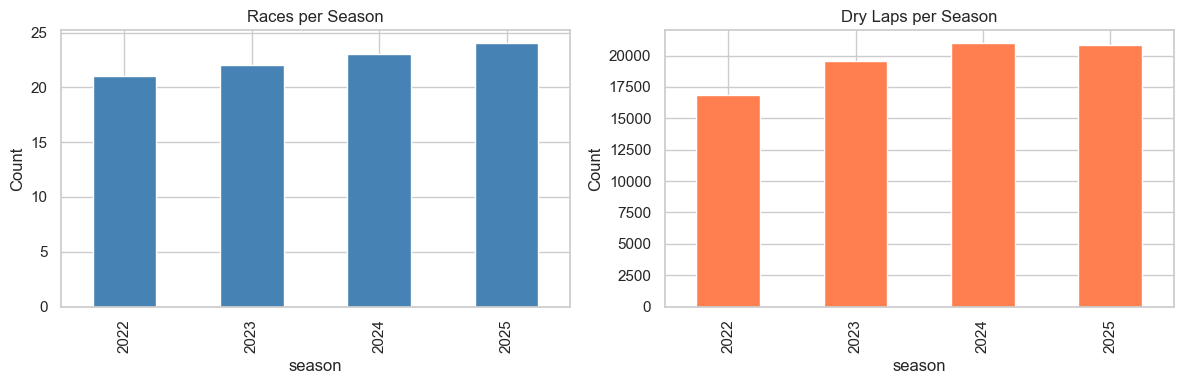

In [7]:
season_stats = df.groupby("season").agg(
    races=("race_id", "nunique"),
    laps=("lap_time_seconds", "count"),
    drivers=("driver_id", "nunique"),
    circuits=("circuit_id", "nunique"),
)
display(season_stats)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
season_stats["races"].plot.bar(ax=axes[0], color="steelblue")
axes[0].set_title("Races per Season")
axes[0].set_ylabel("Count")
season_stats["laps"].plot.bar(ax=axes[1], color="coral")
axes[1].set_title("Dry Laps per Season")
axes[1].set_ylabel("Count")
plt.tight_layout()
plt.show()

### Laps per race distribution

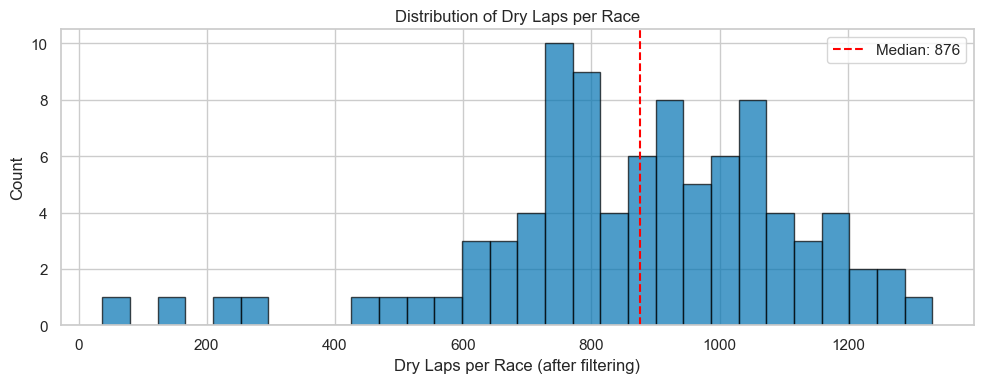


Races with fewest dry laps (bottom 10%) — may have been rain-affected:
  2025_01 (Australian Grand Prix): 37 dry laps
  2025_12 (British Grand Prix): 146 dry laps
  2024_09 (Canadian Grand Prix): 233 dry laps
  2022_17 (Singapore Grand Prix): 270 dry laps
  2022_07 (Monaco Grand Prix): 461 dry laps
  2025_06 (Miami Grand Prix): 476 dry laps
  2025_13 (Belgian Grand Prix): 531 dry laps
  2023_21 (Las Vegas Grand Prix): 587 dry laps
  2022_10 (British Grand Prix): 624 dry laps


In [8]:
laps_per_race = df.groupby("race_id").size().rename("n_laps")

fig, ax = plt.subplots(figsize=(10, 4))
laps_per_race.hist(bins=30, ax=ax, edgecolor="black", alpha=0.7)
ax.axvline(
    laps_per_race.median(), color="red", ls="--", label=f"Median: {laps_per_race.median():.0f}"
)
ax.set_xlabel("Dry Laps per Race (after filtering)")
ax.set_ylabel("Count")
ax.set_title("Distribution of Dry Laps per Race")
ax.legend()
plt.tight_layout()
plt.show()

low_lap_races = laps_per_race[laps_per_race < laps_per_race.quantile(0.1)]
print("\nRaces with fewest dry laps (bottom 10%) — may have been rain-affected:")
race_circuit = df.groupby("race_id")["circuit_id"].first()
for rid, n in low_lap_races.sort_values().items():
    print(f"  {rid} ({race_circuit[rid]}): {n} dry laps")

### Driver presence across seasons

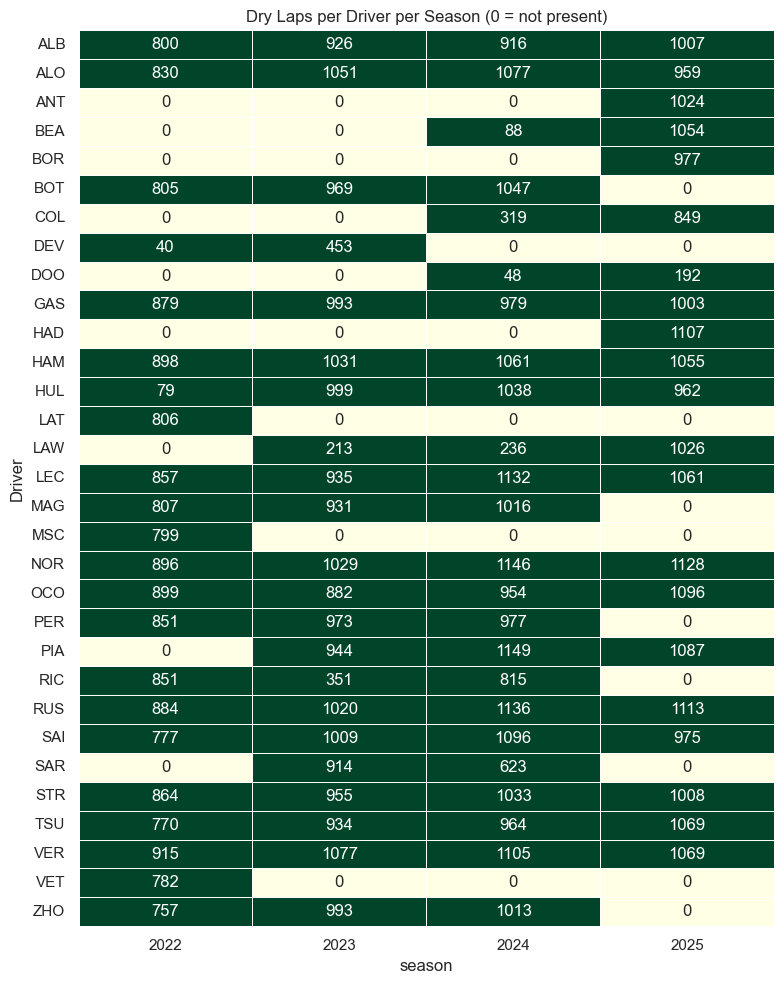

In [9]:
driver_season = df.groupby(["driver_id", "season"]).size().unstack(fill_value=0)

fig, ax = plt.subplots(figsize=(8, 10))
sns.heatmap(
    driver_season.gt(0).astype(int),
    cmap="YlGn",
    cbar=False,
    linewidths=0.5,
    annot=driver_season,
    fmt="d",
    ax=ax,
)
ax.set_title("Dry Laps per Driver per Season (0 = not present)")
ax.set_ylabel("Driver")
plt.tight_layout()
plt.show()

### Compound usage per race

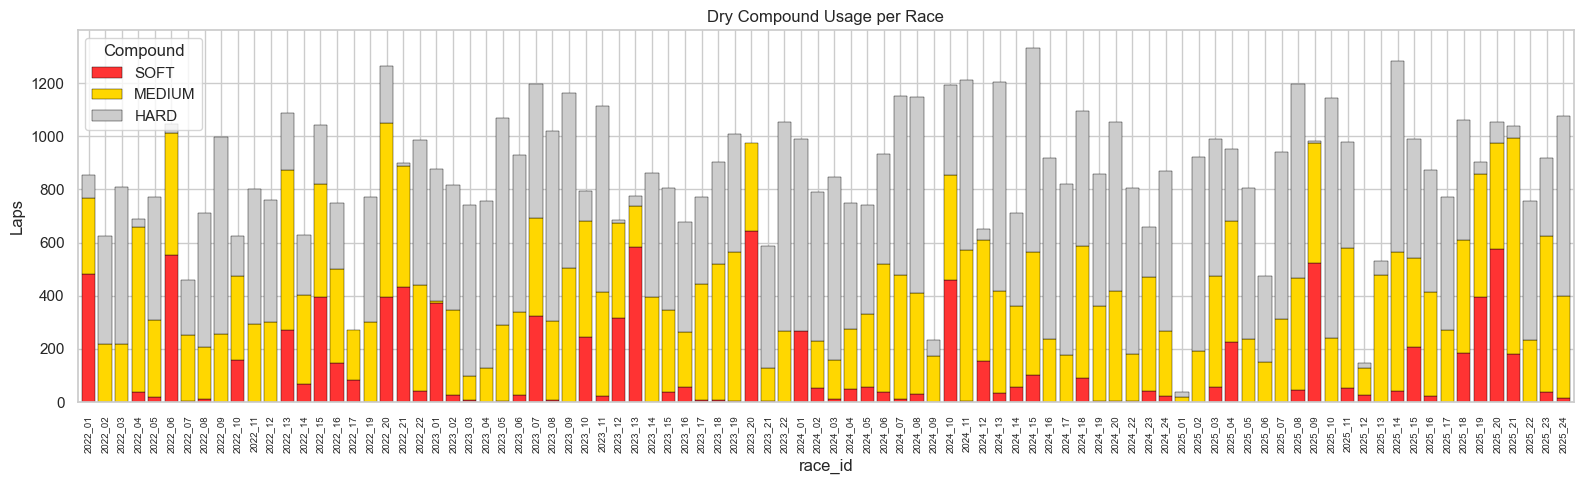


Compound distribution:
compound
HARD      37852
MEDIUM    30453
SOFT       9912
Name: count, dtype: int64


In [10]:
compound_colors = {"SOFT": "#FF3333", "MEDIUM": "#FFD700", "HARD": "#CCCCCC"}

compound_race = df.groupby(["race_id", "compound"]).size().unstack(fill_value=0)
cols_order = [c for c in ["SOFT", "MEDIUM", "HARD"] if c in compound_race.columns]
compound_race = compound_race[cols_order]

fig, ax = plt.subplots(figsize=(16, 5))
compound_race.plot.bar(
    stacked=True,
    ax=ax,
    color=[compound_colors[c] for c in cols_order],
    edgecolor="black",
    linewidth=0.3,
    width=0.8,
)
ax.set_title("Dry Compound Usage per Race")
ax.set_ylabel("Laps")
ax.tick_params(axis="x", rotation=90, labelsize=7)
ax.legend(title="Compound")
plt.tight_layout()
plt.show()

print("\nCompound distribution:")
print(df["compound"].value_counts())

### Circuits across seasons

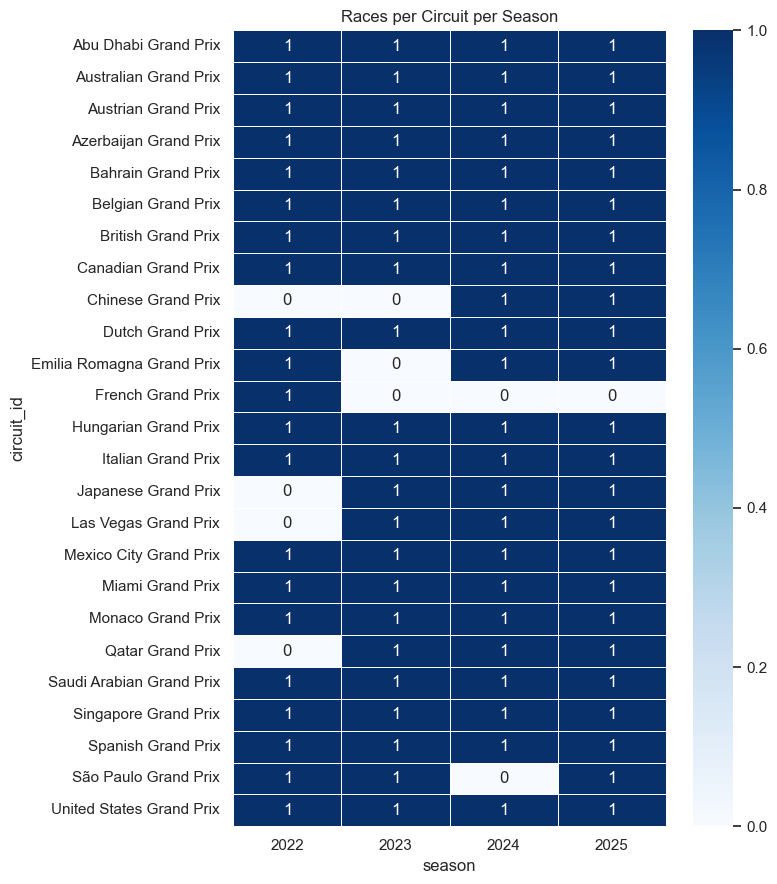

In [11]:
circuit_season = df.groupby(["circuit_id", "season"])["race_id"].nunique().unstack(fill_value=0)
fig, ax = plt.subplots(figsize=(8, 9))
sns.heatmap(circuit_season, annot=True, fmt="d", cmap="Blues", linewidths=0.5, ax=ax)
ax.set_title("Races per Circuit per Season")
plt.tight_layout()
plt.show()

## 3. Missingness Analysis

3 columns have missing values:



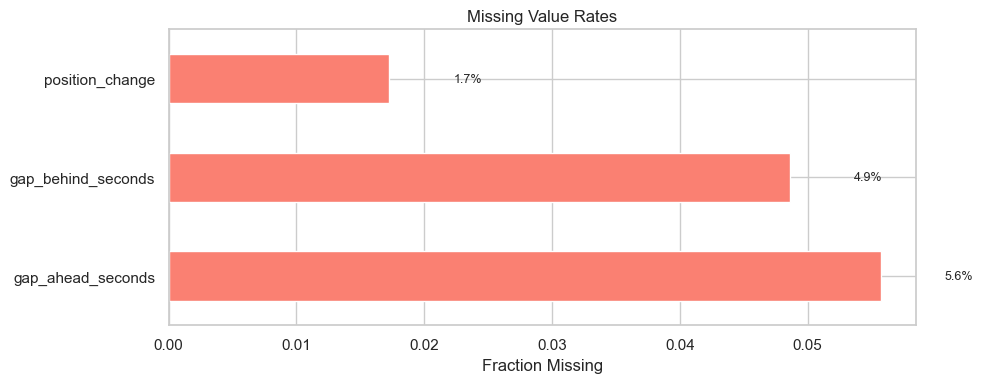

In [12]:
null_pct = df.isnull().mean().sort_values(ascending=False)
null_cols = null_pct[null_pct > 0]

if len(null_cols) == 0:
    print("No missing values in any column!")
else:
    print(f"{len(null_cols)} columns have missing values:\n")
    fig, ax = plt.subplots(figsize=(10, max(4, len(null_cols) * 0.35)))
    null_cols.plot.barh(ax=ax, color="salmon")
    ax.set_xlabel("Fraction Missing")
    ax.set_title("Missing Value Rates")
    for i, v in enumerate(null_cols):
        ax.text(v + 0.005, i, f"{v:.1%}", va="center", fontsize=9)
    plt.tight_layout()
    plt.show()

### Gap features missingness

In [13]:
gap_cols = ["gap_ahead_seconds", "gap_behind_seconds"]
existing_gap = [c for c in gap_cols if c in df.columns]
if existing_gap:
    for col in existing_gap:
        n_null = df[col].isnull().sum()
        n_zero = (df[col] == 0).sum()
        print(f"{col}: {n_null} NaN ({n_null / len(df):.1%}), {n_zero} zeros")
    if "gap_ahead_seconds" in df.columns:
        print("\ngap_ahead NaN by position (top 5):")
        print(df[df["gap_ahead_seconds"].isnull()]["position"].value_counts().head())

gap_ahead_seconds: 4358 NaN (5.6%), 0 zeros
gap_behind_seconds: 3805 NaN (4.9%), 3 zeros

gap_ahead NaN by position (top 5):
position
1.0    4358
Name: count, dtype: int64


## 4. Target Variable: lap_time_seconds

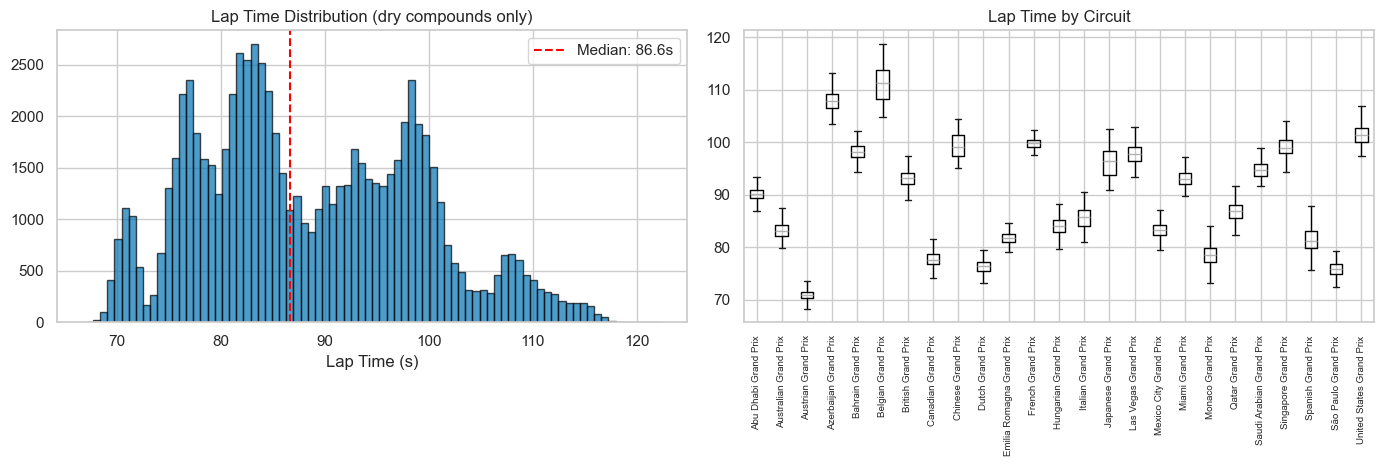

Lap time range: 67.0s - 122.1s
Laps > 120s: 6 (0.01%)
Laps < 60s: 0


In [14]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
df["lap_time_seconds"].hist(bins=80, ax=axes[0], edgecolor="black", alpha=0.7)
axes[0].set_xlabel("Lap Time (s)")
axes[0].set_title("Lap Time Distribution (dry compounds only)")
axes[0].axvline(
    df["lap_time_seconds"].median(),
    color="red",
    ls="--",
    label=f"Median: {df['lap_time_seconds'].median():.1f}s",
)
axes[0].legend()

df.boxplot(
    column="lap_time_seconds", by="circuit_id", ax=axes[1], vert=True, showfliers=False, rot=90
)
axes[1].set_title("Lap Time by Circuit")
axes[1].set_xlabel("")
axes[1].tick_params(axis="x", labelsize=7)
fig.suptitle("")
plt.tight_layout()
plt.show()

print(f"Lap time range: {df['lap_time_seconds'].min():.1f}s - {df['lap_time_seconds'].max():.1f}s")
print(
    f"Laps > 120s: {(df['lap_time_seconds'] > 120).sum()} ({(df['lap_time_seconds'] > 120).mean():.2%})"
)
print(f"Laps < 60s: {(df['lap_time_seconds'] < 60).sum()}")

### Core degradation curve: lap time vs tyre life

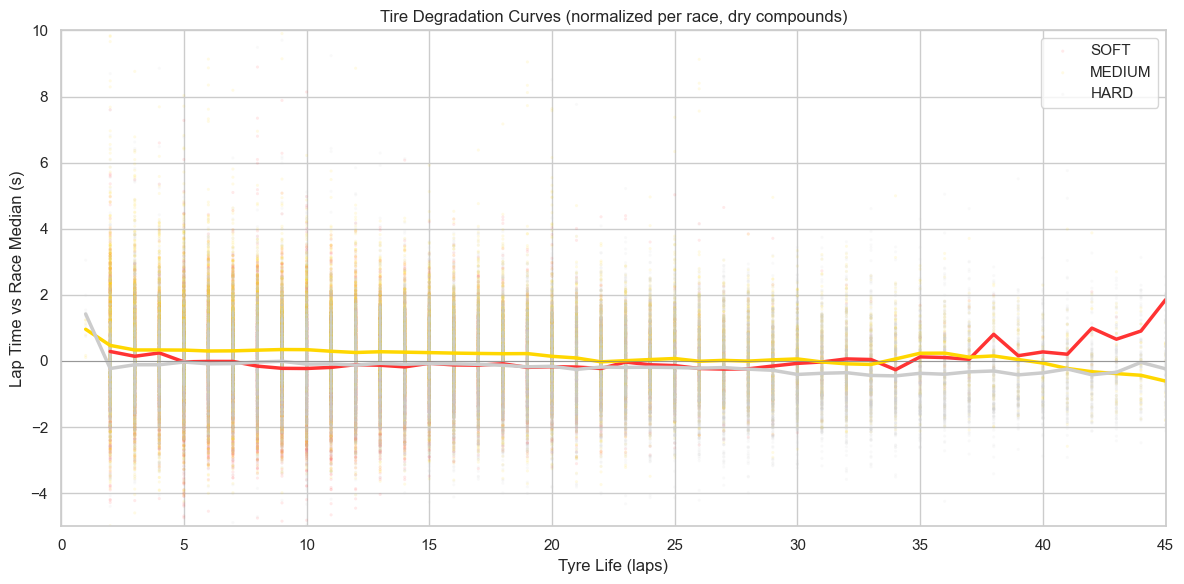

In [15]:
df["lap_time_norm"] = df.groupby("race_id")["lap_time_seconds"].transform(lambda x: x - x.median())

fig, ax = plt.subplots(figsize=(12, 6))
for compound in ["SOFT", "MEDIUM", "HARD"]:
    mask = df["compound"] == compound
    sub = df[mask]
    ax.scatter(
        sub["tyre_life"],
        sub["lap_time_norm"],
        c=compound_colors[compound],
        alpha=0.1,
        s=5,
        label=compound,
        edgecolors="none",
    )
    trend = sub.groupby("tyre_life")["lap_time_norm"].median()
    ax.plot(trend.index, trend.values, color=compound_colors[compound], lw=2.5)

ax.set_xlabel("Tyre Life (laps)")
ax.set_ylabel("Lap Time vs Race Median (s)")
ax.set_title("Tire Degradation Curves (normalized per race, dry compounds)")
ax.set_xlim(0, 45)
ax.set_ylim(-5, 10)
ax.legend()
ax.axhline(0, color="gray", ls="-", lw=0.5)
plt.tight_layout()
plt.show()

## 5. Key Feature Distributions

### Tyre life

,mean,50%,max
compound,,,
HARD,27.080675,26.0,78.0
MEDIUM,19.726269,19.0,77.0
SOFT,16.625162,16.0,49.0


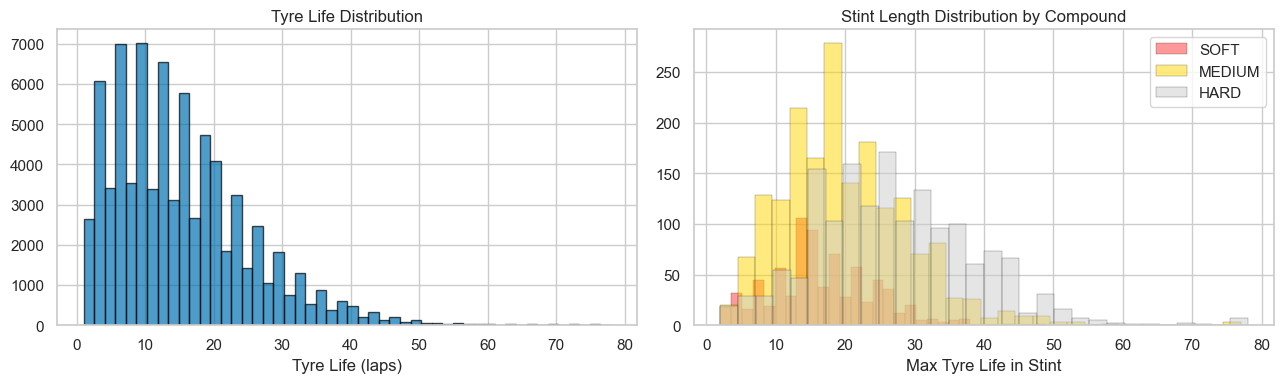

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
df["tyre_life"].hist(bins=50, ax=axes[0], edgecolor="black", alpha=0.7)
axes[0].set_xlabel("Tyre Life (laps)")
axes[0].set_title("Tyre Life Distribution")

max_stint = df.groupby(["race_id", "driver_id", "stint_number", "compound"])["tyre_life"].max()
max_stint_by_compound = max_stint.groupby("compound").describe()[["mean", "50%", "max"]]
display(max_stint_by_compound)

for compound in ["SOFT", "MEDIUM", "HARD"]:
    data = (
        max_stint.xs(compound, level="compound")
        if compound in max_stint.index.get_level_values("compound")
        else pd.Series()
    )
    if len(data) > 0:
        axes[1].hist(
            data,
            bins=30,
            alpha=0.5,
            label=compound,
            color=compound_colors[compound],
            edgecolor="black",
            linewidth=0.3,
        )
axes[1].set_xlabel("Max Tyre Life in Stint")
axes[1].set_title("Stint Length Distribution by Compound")
axes[1].legend()
plt.tight_layout()
plt.show()

### Circuit characteristics

,track_length_km,n_corners,tire_stress,pit_loss_seconds
circuit_id,,,,
Monaco Grand Prix,3.337,19,1,24.0
Dutch Grand Prix,4.259,14,4,23.5
Mexico City Grand Prix,4.304,17,3,23.5
São Paulo Grand Prix,4.309,15,4,22.5
Austrian Grand Prix,4.318,10,3,21.5
Canadian Grand Prix,4.361,14,2,22.5
Hungarian Grand Prix,4.381,14,3,23.5
Spanish Grand Prix,4.657,16,4,23.0
Emilia Romagna Grand Prix,4.909,19,3,23.0


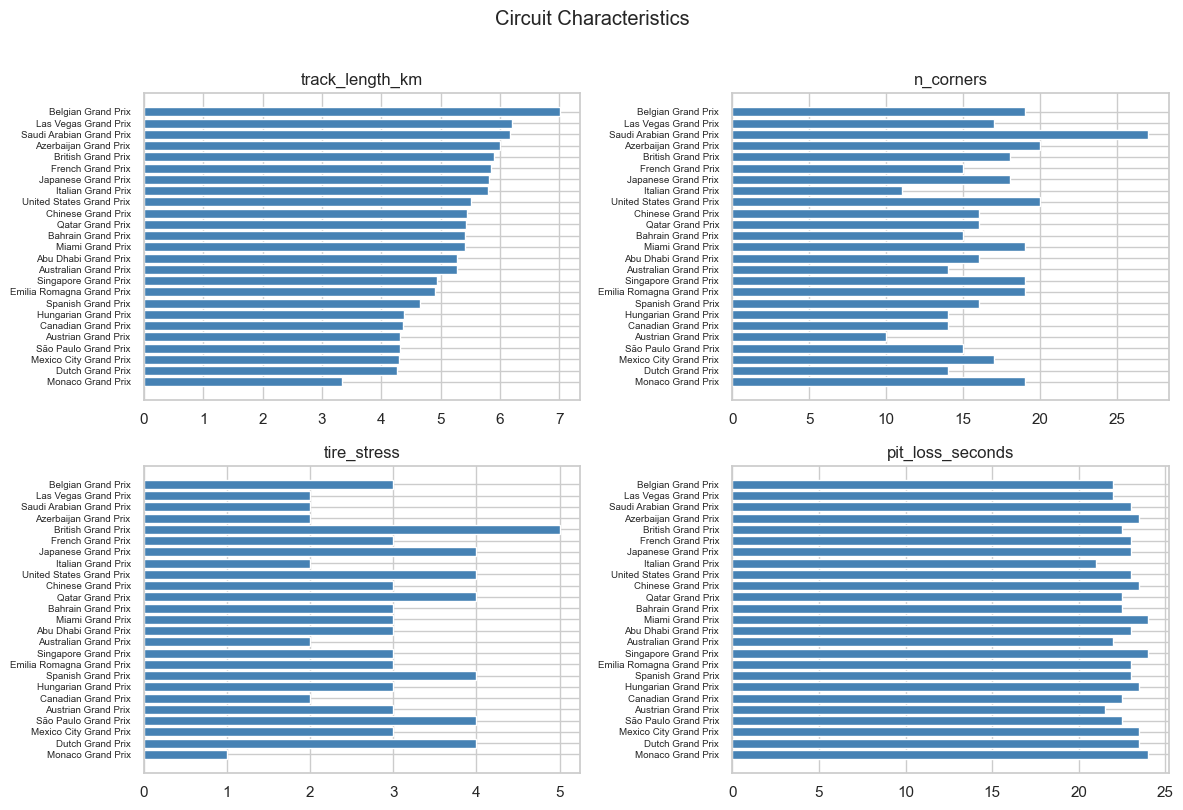

In [17]:
circuit_feat_cols = ["track_length_km", "n_corners", "tire_stress", "pit_loss_seconds"]
existing_circuit = [c for c in circuit_feat_cols if c in df.columns]

if existing_circuit:
    circuit_chars = (
        df.groupby("circuit_id")[existing_circuit].first().sort_values("track_length_km")
    )
    display(circuit_chars)

    fig, axes = plt.subplots(2, 2, figsize=(12, 8))
    for ax, col in zip(axes.flat, existing_circuit, strict=False):
        vals = circuit_chars[col]
        ax.barh(range(len(vals)), vals.values, color="steelblue")
        ax.set_yticks(range(len(vals)))
        ax.set_yticklabels(vals.index, fontsize=7)
        ax.set_title(col)
    plt.suptitle("Circuit Characteristics", y=1.01)
    plt.tight_layout()
    plt.show()
else:
    print("No circuit characteristic features found")

### Fuel mass

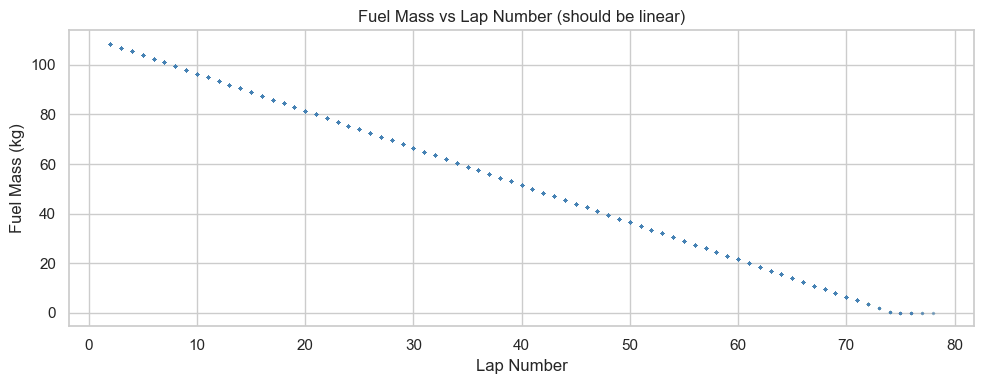

Fuel range: 0.0 - 108.5 kg
Negative fuel values: 0


In [18]:
fig, ax = plt.subplots(figsize=(10, 4))
ax.scatter(df["lap_number"], df["fuel_mass_kg"], alpha=0.05, s=2, color="steelblue")
ax.set_xlabel("Lap Number")
ax.set_ylabel("Fuel Mass (kg)")
ax.set_title("Fuel Mass vs Lap Number (should be linear)")
plt.tight_layout()
plt.show()
print(f"Fuel range: {df['fuel_mass_kg'].min():.1f} - {df['fuel_mass_kg'].max():.1f} kg")
print(f"Negative fuel values: {(df['fuel_mass_kg'] < 0).sum()}")

### Weather features

/Users/philipredford/personal/formula1/.venv/lib/python3.13/site-packages/matplotlib/axes/_axes.py:7132: RuntimeWarning: Converting input from bool to <class 'numpy.uint8'> for compatibility.
  m, bins = np.histogram(x[i], bins, weights=w[i], **hist_kwargs)


TypeError: numpy boolean subtract, the `-` operator, is not supported, use the bitwise_xor, the `^` operator, or the logical_xor function instead.

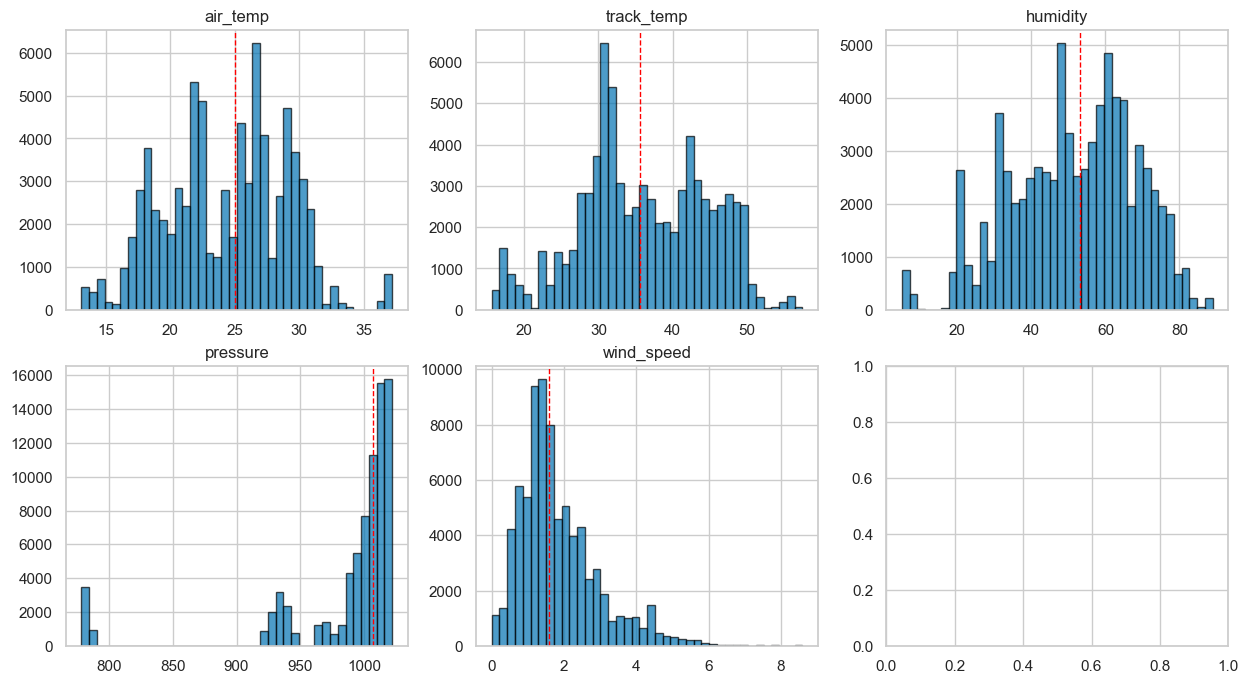

In [19]:
weather_cols = ["air_temp", "track_temp", "humidity", "pressure", "wind_speed", "rainfall"]
existing_weather = [c for c in weather_cols if c in df.columns]
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
for ax, col in zip(axes.flat, existing_weather, strict=False):
    df[col].hist(bins=40, ax=ax, edgecolor="black", alpha=0.7)
    ax.set_title(col)
    ax.axvline(df[col].median(), color="red", ls="--", lw=1)
for ax in axes.flat[len(existing_weather) :]:
    ax.set_visible(False)
plt.suptitle("Weather Feature Distributions", y=1.02)
plt.tight_layout()
plt.show()
print(f"\nRainfall > 0: {(df['rainfall'] > 0).sum()} laps ({(df['rainfall'] > 0).mean():.2%})")
print("(Note: some dry-compound laps occur during light rain)")

### Traffic & position

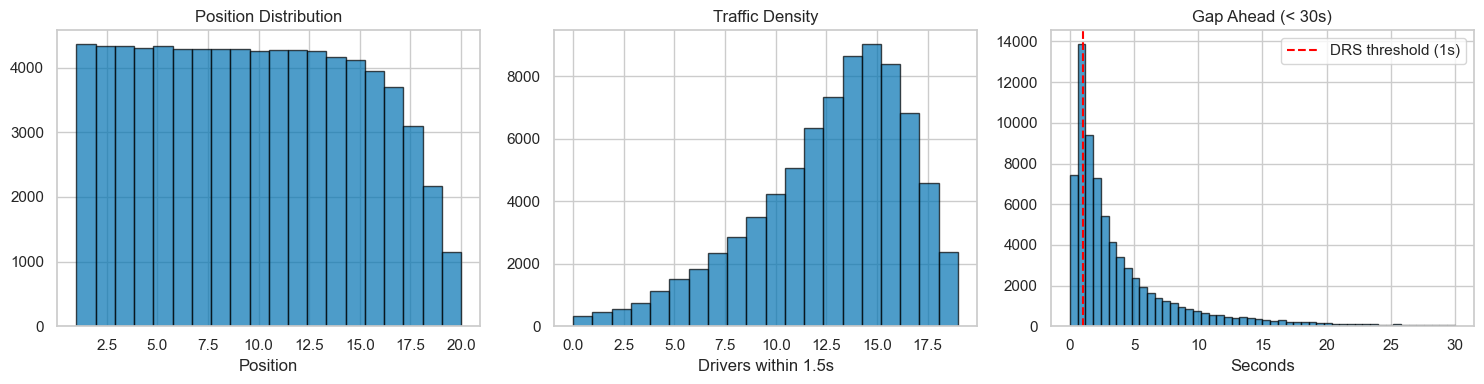

In [20]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
df["position"].hist(bins=20, ax=axes[0], edgecolor="black", alpha=0.7)
axes[0].set_title("Position Distribution")
axes[0].set_xlabel("Position")
df["traffic_density"].hist(bins=20, ax=axes[1], edgecolor="black", alpha=0.7)
axes[1].set_title("Traffic Density")
axes[1].set_xlabel("Drivers within 1.5s")
gap_data = df["gap_ahead_seconds"].dropna()
gap_data[gap_data < 30].hist(bins=50, ax=axes[2], edgecolor="black", alpha=0.7)
axes[2].set_title("Gap Ahead (< 30s)")
axes[2].set_xlabel("Seconds")
axes[2].axvline(1.0, color="red", ls="--", label="DRS threshold (1s)")
axes[2].legend()
plt.tight_layout()
plt.show()

## 6. Feature Correlations

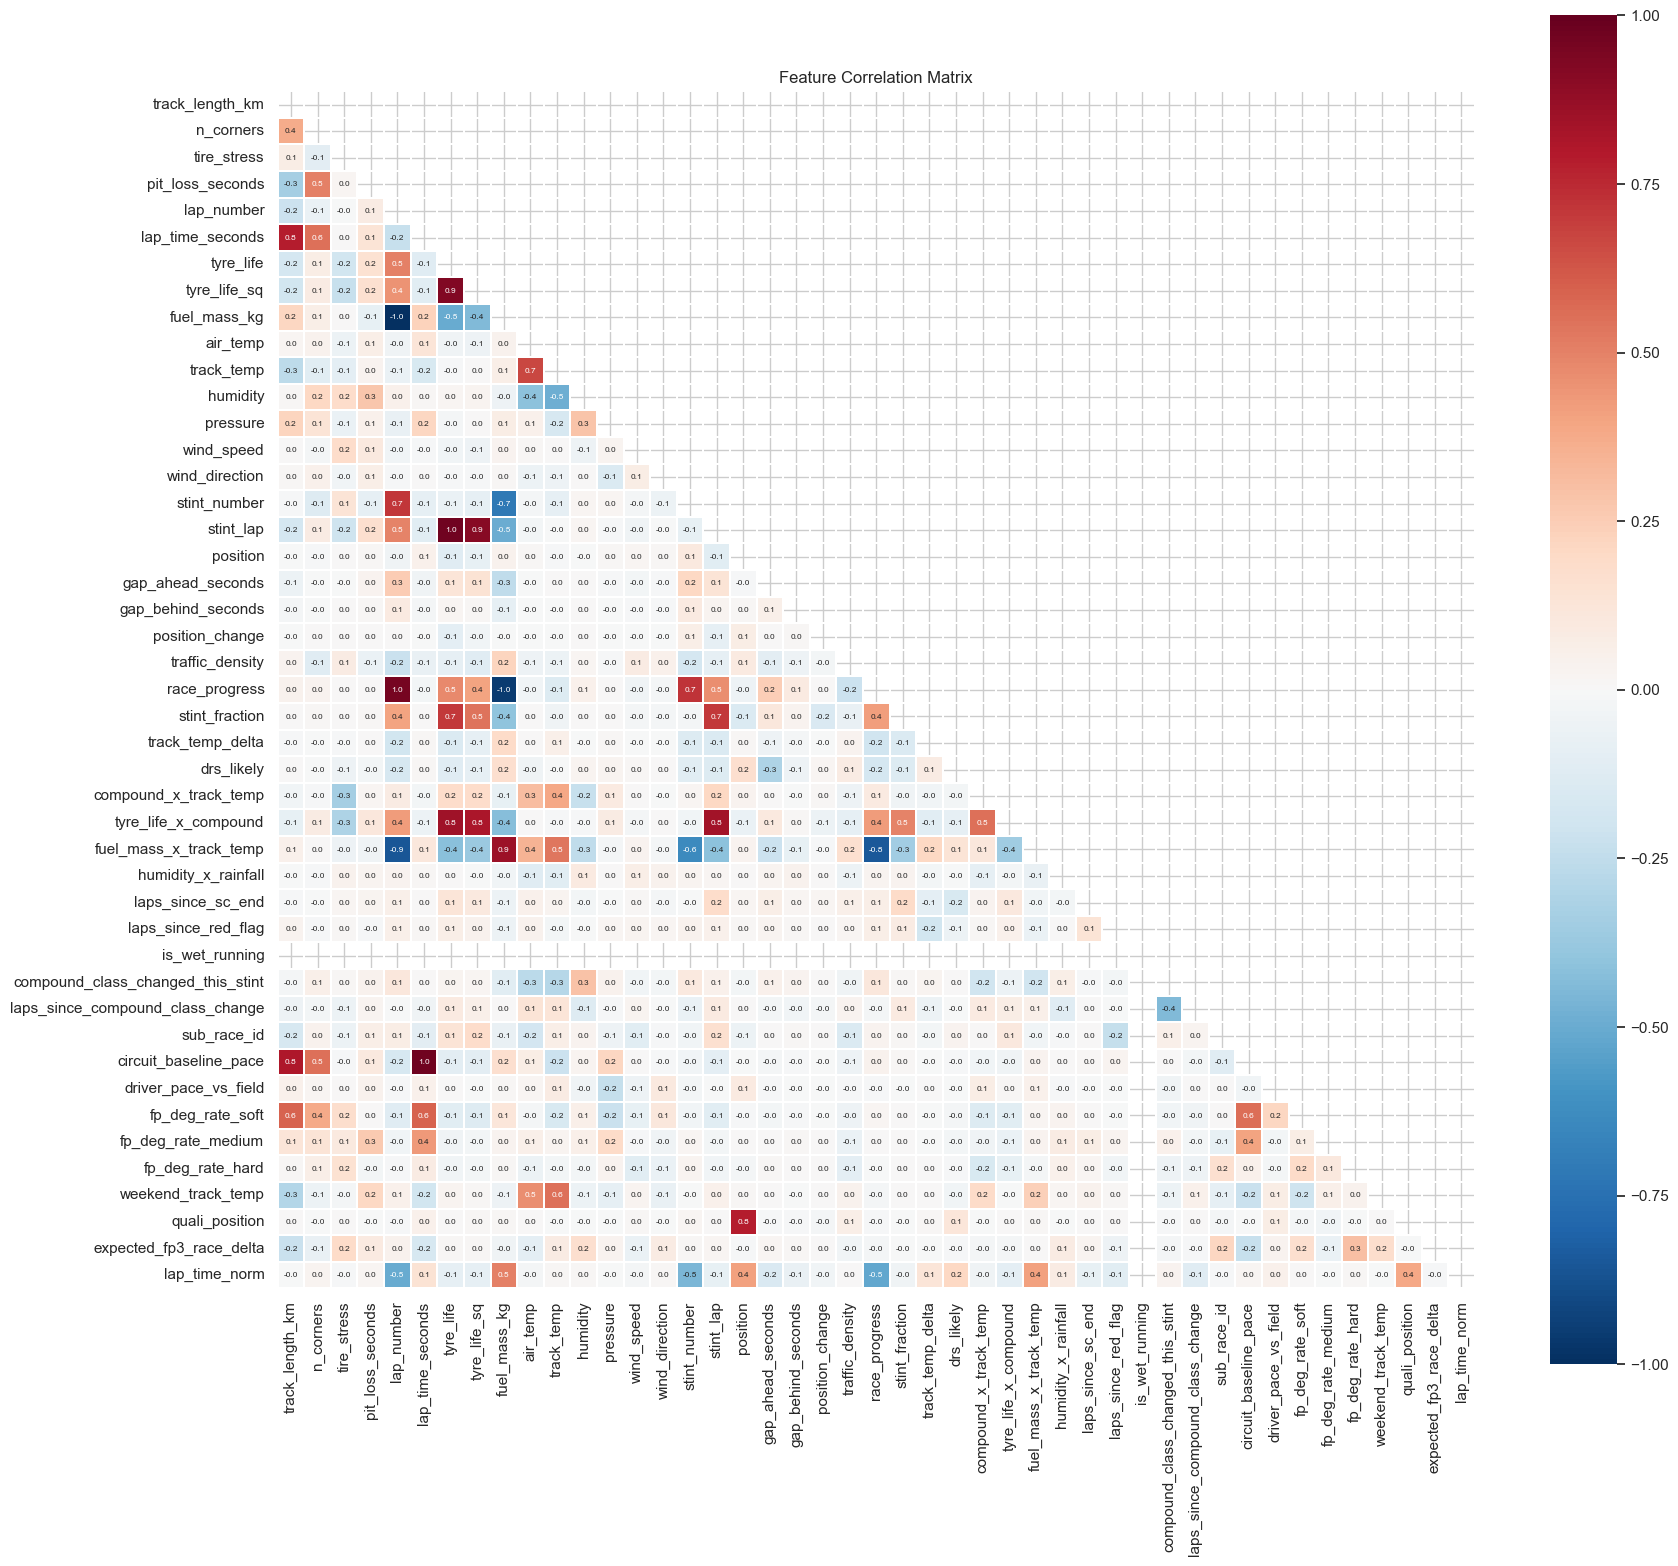

In [21]:
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
exclude = ["season"]
numeric_cols = [c for c in numeric_cols if c not in exclude]
corr = df[numeric_cols].corr()

fig, ax = plt.subplots(figsize=(18, 16))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(
    corr,
    mask=mask,
    cmap="RdBu_r",
    center=0,
    vmin=-1,
    vmax=1,
    ax=ax,
    fmt=".1f",
    linewidths=0.3,
    square=True,
    annot=True,
    annot_kws={"size": 6},
)
ax.set_title("Feature Correlation Matrix")
plt.tight_layout()
plt.show()

In [22]:
high_corr = []
for i in range(len(corr.columns)):
    for j in range(i + 1, len(corr.columns)):
        if abs(corr.iloc[i, j]) > 0.9:
            high_corr.append((corr.columns[i], corr.columns[j], corr.iloc[i, j]))

if high_corr:
    print("Highly correlated feature pairs (|r| > 0.9):")
    for a, b, r in sorted(high_corr, key=lambda x: -abs(x[2])):
        print(f"  {a} <-> {b}: {r:.3f}")
else:
    print("No feature pairs with |r| > 0.9")

Highly correlated feature pairs (|r| > 0.9):
  lap_number <-> fuel_mass_kg: -1.000
  lap_time_seconds <-> circuit_baseline_pace: 0.972
  tyre_life <-> stint_lap: 0.972
  fuel_mass_kg <-> race_progress: -0.957
  lap_number <-> race_progress: 0.957
  tyre_life <-> tyre_life_sq: 0.930
  tyre_life_sq <-> stint_lap: 0.913


## 7. Potential Issues & Flags

### Safety car features

Laps within 5 of SC end: 6363 (8.14%)
Races with SC: 60 / 90


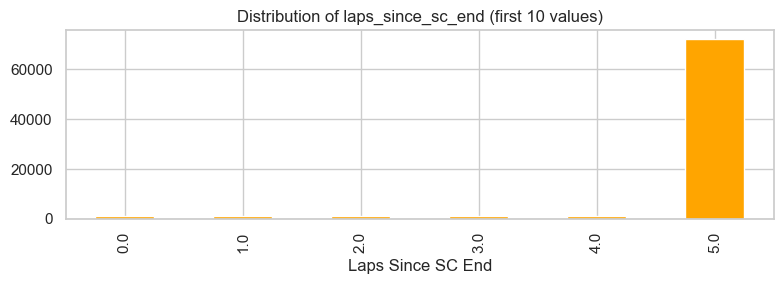

In [23]:
if "laps_since_sc_end" in df.columns:
    sc_affected = df[df["laps_since_sc_end"] < 5]
    print(f"Laps within 5 of SC end: {len(sc_affected)} ({len(sc_affected) / len(df):.2%})")
    print(
        f"Races with SC: {df[df['had_sc_this_stint']]['race_id'].nunique()} / {df['race_id'].nunique()}"
    )
    fig, ax = plt.subplots(figsize=(8, 3))
    df["laps_since_sc_end"].value_counts().sort_index().head(10).plot.bar(ax=ax, color="orange")
    ax.set_title("Distribution of laps_since_sc_end (first 10 values)")
    ax.set_xlabel("Laps Since SC End")
    plt.tight_layout()
    plt.show()

### Weekend feature quality check

FP degradation rate statistics:


,fp_deg_rate_soft,fp_deg_rate_medium,fp_deg_rate_hard
count,78217.000000,78217.000000,78217.000000
mean,0.295783,0.157827,0.117111
std,0.087183,0.078573,0.045628
min,0.011875,0.001758,0.002830
25%,0.233790,0.093774,0.092086
50%,0.295055,0.143950,0.117972
75%,0.362931,0.199945,0.140617
max,0.499856,0.499235,0.478761


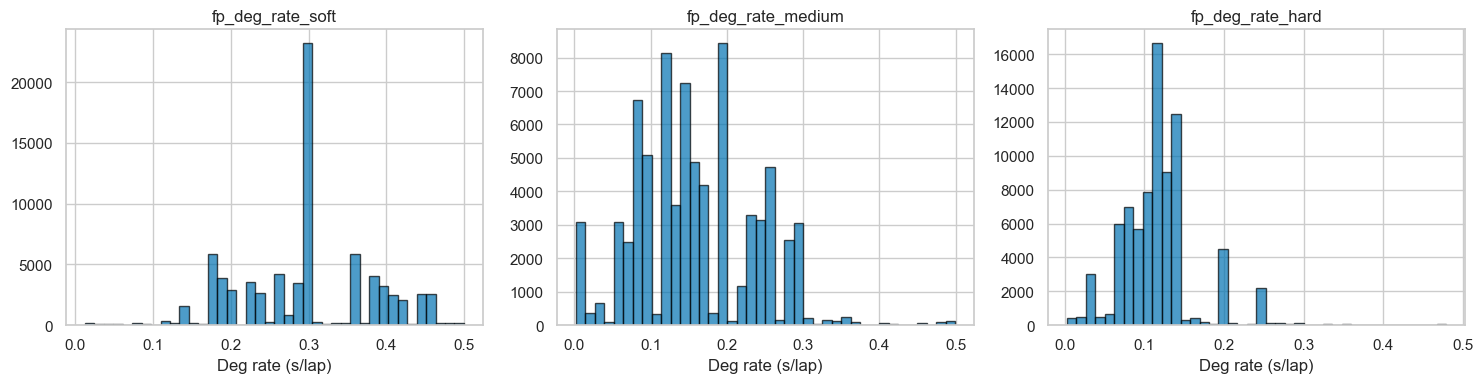

In [24]:
deg_cols = [
    c for c in ["fp_deg_rate_soft", "fp_deg_rate_medium", "fp_deg_rate_hard"] if c in df.columns
]
if deg_cols:
    print("FP degradation rate statistics:")
    display(df[deg_cols].describe())
    fig, axes = plt.subplots(1, len(deg_cols), figsize=(5 * len(deg_cols), 4))
    if len(deg_cols) == 1:
        axes = [axes]
    for ax, col in zip(axes, deg_cols, strict=False):
        data = df[col].dropna()
        data.hist(bins=40, ax=ax, edgecolor="black", alpha=0.7)
        ax.set_title(col)
        ax.set_xlabel("Deg rate (s/lap)")
        n_neg = (data < 0).sum()
        n_high = (data > 0.5).sum()
        if n_neg > 0 or n_high > 0:
            ax.text(
                0.95,
                0.95,
                f"Neg: {n_neg}, >0.5: {n_high}",
                transform=ax.transAxes,
                ha="right",
                va="top",
                fontsize=9,
                color="red",
            )
    plt.tight_layout()
    plt.show()

### 2025 season coverage

In [25]:
if 2025 in df["season"].values:
    s25 = df[df["season"] == 2025]
    print(f"2025 season: {s25['race_id'].nunique()} races, {len(s25)} dry laps")
    print(f"Circuits: {s25['circuit_id'].unique().tolist()}")
    print(f"Race IDs: {sorted(s25['race_id'].unique().tolist())}")
else:
    print("No 2025 data present")

2025 season: 24 races, 20821 dry laps
Circuits: ['Australian Grand Prix', 'Chinese Grand Prix', 'Japanese Grand Prix', 'Bahrain Grand Prix', 'Saudi Arabian Grand Prix', 'Miami Grand Prix', 'Emilia Romagna Grand Prix', 'Monaco Grand Prix', 'Spanish Grand Prix', 'Canadian Grand Prix', 'Austrian Grand Prix', 'British Grand Prix', 'Belgian Grand Prix', 'Hungarian Grand Prix', 'Dutch Grand Prix', 'Italian Grand Prix', 'Azerbaijan Grand Prix', 'Singapore Grand Prix', 'United States Grand Prix', 'Mexico City Grand Prix', 'São Paulo Grand Prix', 'Las Vegas Grand Prix', 'Qatar Grand Prix', 'Abu Dhabi Grand Prix']
Race IDs: ['2025_01', '2025_02', '2025_03', '2025_04', '2025_05', '2025_06', '2025_07', '2025_08', '2025_09', '2025_10', '2025_11', '2025_12', '2025_13', '2025_14', '2025_15', '2025_16', '2025_17', '2025_18', '2025_19', '2025_20', '2025_21', '2025_22', '2025_23', '2025_24']


## 8. Summary

In [26]:
summary = {
    "Total dry laps": len(df),
    "Races": df["race_id"].nunique(),
    "Seasons": sorted(df["season"].unique().tolist()),
    "Circuits": df["circuit_id"].nunique(),
    "Drivers": df["driver_id"].nunique(),
    "Features": len(df.columns),
    "Compounds": "SOFT, MEDIUM, HARD (dry only)",
    "Columns with NaN": int((df.isnull().any()).sum()),
    "Max NaN rate": f"{df.isnull().mean().max():.1%}",
    "Lap time range": f"{df['lap_time_seconds'].min():.1f}s - {df['lap_time_seconds'].max():.1f}s",
    "Median lap time": f"{df['lap_time_seconds'].median():.1f}s",
}

issues = []
max_null = df.isnull().mean().max()
if max_null > 0.1:
    worst_col = df.isnull().mean().idxmax()
    issues.append(f"High missingness: {worst_col} ({max_null:.1%})")
high_corr_pairs = len(high_corr) if "high_corr" in dir() else 0
if high_corr_pairs > 0:
    issues.append(f"{high_corr_pairs} highly correlated feature pairs (|r|>0.9)")
n_extreme = (df["lap_time_seconds"] > 120).sum()
if n_extreme > 100:
    issues.append(f"{n_extreme} laps > 120s still in clean data")
if 2025 in df["season"].values:
    n_2025 = df[df["season"] == 2025]["race_id"].nunique()
    issues.append(f"2025 season partial ({n_2025} races)")
for c in ["track_length_km", "n_corners", "tire_stress", "pit_loss_seconds"]:
    if c in df.columns and df[c].isna().any():
        issues.append(f"{c} has {df[c].isna().sum()} NaN values")

print("=" * 60)
print("DATA COVERAGE SUMMARY (DRY-ONLY)")
print("=" * 60)
for k, v in summary.items():
    print(f"  {k:.<30} {v}")
print(f"\nPOTENTIAL ISSUES ({len(issues)}):")
for i, issue in enumerate(issues, 1):
    print(f"  {i}. {issue}")
if not issues:
    print("  None detected!")

DATA COVERAGE SUMMARY (DRY-ONLY)
  Total dry laps................ 78217
  Races......................... 90
  Seasons....................... [2022, 2023, 2024, 2025]
  Circuits...................... 25
  Drivers....................... 31
  Features...................... 56
  Compounds..................... SOFT, MEDIUM, HARD (dry only)
  Columns with NaN.............. 3
  Max NaN rate.................. 5.6%
  Lap time range................ 67.0s - 122.1s
  Median lap time............... 86.6s

POTENTIAL ISSUES (2):
  1. 7 highly correlated feature pairs (|r|>0.9)
  2. 2025 season partial (24 races)


In [27]:
df.drop(columns=["season", "lap_time_norm"], inplace=True, errors="ignore")